# NB22 — New Signals: Thai Bond Yields, THD Foreign Demand, VIX Term Structure

Tests three alternative data signals for alpha enhancement:

| Signal | Source | Hypothesis |
|--------|--------|-----------|
| **TH yield slope** (10Y–1Y) | Bank of Thailand API | Steepening = risk-on → bullish SET |
| **THD vs EEM relative return** | yfinance (NYSE-listed ETF) | Foreign excess demand for Thailand → momentum |
| **VIX term structure** (VIX3M − VIX) | yfinance (CBOE) | Backwardation (fear spike) = contrarian buy |

Methodology: IC vs 1-week forward SET return, regime analysis, system integration.

> **Note:** SET investor-type API and TFEX PCR API are blocked by Incapsula WAF.
> We use yfinance proxies: THD ETF tracks MSCI Thailand (US-listed, reflects foreign demand),
> VIX3M/VIX term structure is a proxy for options market fear/complacency.


## 1. Setup & Data


In [1]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

ROOT = Path('..').resolve().parent
RAW  = ROOT / 'data' / 'raw'
DATA = ROOT / 'data' / 'processed'
FIGS = Path('.') / 'figs'
FIGS.mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3,
})
WEEKS_PER_YEAR = 52
RF_ANNUAL      = 0.02
TC_ONE_WAY     = 0.001
START          = '2010-01-01'

In [2]:
# Base SET return series from unified_weekly_clean
df_base = pd.read_csv(DATA / 'unified_weekly_clean.csv',
                      index_col=0, parse_dates=True).sort_index()
df_base = df_base.loc[START:]

set_ret  = df_base['SET_index_ret_w']
gold_ret = df_base['gold_ret_w']
eem_ret  = df_base['eem_ret_d_lag1'] if 'eem_ret_d_lag1' in df_base.columns else None

print(f'Base data: {df_base.shape[0]} weeks  '
      f'{df_base.index[0].date()} -> {df_base.index[-1].date()}')
print(f'SET return — mean: {set_ret.mean()*52:.1%}  std: {set_ret.std()*52**0.5:.1%}')

Base data: 835 weeks  2010-01-01 -> 2025-12-26
SET return — mean: 5.2%  std: 14.4%


In [3]:
def compute_ic(signal: pd.Series, forward_ret: pd.Series,
               lag: int = 1, label: str = '') -> dict:
    '''Spearman rank IC — signal lagged by `lag` weeks before correlating.'''
    sig_lagged = signal.shift(lag)
    both = pd.concat([sig_lagged, forward_ret], axis=1).dropna()
    both.columns = ['sig', 'ret']
    r, p = stats.spearmanr(both['sig'], both['ret'])
    n = len(both)
    stars = '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.1 else ''))
    print(f'  IC {label:40s}: {r:+.4f}  p={p:.3f} {stars}  n={n}')
    return {'label': label, 'IC': r, 'p': p, 'n': n, 'stars': stars}

ic_results = []

## 2. Signal 1 — Thai Yield Curve Slope (10Y – 1Y)

A steep Thai yield curve signals healthy domestic growth expectations.
Source: Bank of Thailand Open API (monthly data, forward-filled to weekly).

**Feature:** `th_slope = yield_10y − yield_1y` and its 4-month change.


In [4]:
bonds_path = RAW / 'bot_bond_yields.csv'
has_bonds = bonds_path.exists()
print(f'bot_bond_yields.csv  exists: {has_bonds}')
if has_bonds:
    bonds = pd.read_csv(bonds_path, parse_dates=['date'])
    bonds = bonds.set_index('date').sort_index()
    print(bonds[['yield_1y', 'yield_10y', 'th_slope']].tail(5).to_string())
    print(f'Rows: {len(bonds)}  {bonds.index[0].date()} -> {bonds.index[-1].date()}')

bot_bond_yields.csv  exists: True
            yield_1y  yield_10y  th_slope
date                                     
2025-03-01      1.90       2.12      0.22
2025-04-01      1.68       1.92      0.24
2025-05-01      1.57       1.86      0.29
2025-06-01      1.51       1.68      0.17
2025-07-01      1.43       1.54      0.11
Rows: 247  2005-01-01 -> 2025-07-01


In [5]:
if has_bonds:
    # slope = 10Y - 1Y; 4-month change in slope (each obs is 1 month)
    bonds['th_slope']      = bonds['yield_10y'] - bonds['yield_1y']
    bonds['th_slope_chg4'] = bonds['th_slope'].diff(4)

    # Weekly (last obs in each week, forward-fill across weeks)
    bonds_w = bonds[['th_slope', 'th_slope_chg4']].resample('W-FRI').last().ffill()

    # Align to SET index
    sig_slope      = bonds_w['th_slope'].reindex(set_ret.index).ffill()
    sig_slope_chg  = bonds_w['th_slope_chg4'].reindex(set_ret.index).ffill()

    print(f'Mean slope: {bonds_w["th_slope"].mean():.2f}pp  '
          f'Std: {bonds_w["th_slope"].std():.2f}pp')
    print()
    print('IC analysis — Thai bond yield slope:')
    ic_results.append(compute_ic(sig_slope,     set_ret, lag=1, label='TH slope level (lag1)'))
    ic_results.append(compute_ic(sig_slope_chg, set_ret, lag=1, label='TH slope 4m change (lag1)'))
    ic_results.append(compute_ic(sig_slope,     set_ret, lag=2, label='TH slope level (lag2)'))
else:
    print('No bond data — run: python3 scripts/fetch_bot_bonds.py')
    sig_slope = sig_slope_chg = None

Mean slope: 1.06pp  Std: 0.64pp

IC analysis — Thai bond yield slope:
  IC TH slope level (lag1)                   : +0.0333  p=0.336   n=834
  IC TH slope 4m change (lag1)               : -0.0348  p=0.315   n=834
  IC TH slope level (lag2)                   : +0.0313  p=0.367   n=833


  Inverted/Flat  : AnnRet = +4.1%  n=282
  Normal         : AnnRet = +9.6%  n=282
  Steep          : AnnRet = +1.8%  n=270


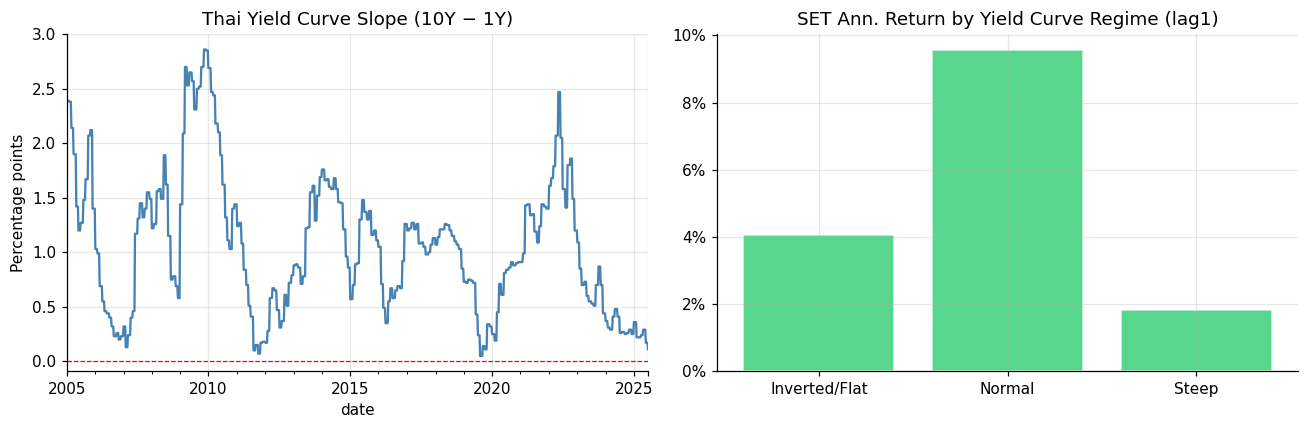

In [6]:
if has_bonds and sig_slope is not None:
    # Regime: slope terciles
    sig_lag = sig_slope.shift(1)
    q33, q67 = sig_lag.quantile([0.33, 0.67])
    regime = pd.cut(sig_lag, bins=[-np.inf, q33, q67, np.inf],
                    labels=['Inverted/Flat', 'Normal', 'Steep'])

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    bonds_w['th_slope'].plot(ax=axes[0], color='steelblue')
    axes[0].axhline(0, color='red', lw=0.8, ls='--')
    axes[0].set_title('Thai Yield Curve Slope (10Y − 1Y)')
    axes[0].set_ylabel('Percentage points')

    ret_by_regime = {lbl: set_ret[regime == lbl].mean() * WEEKS_PER_YEAR
                     for lbl in ['Inverted/Flat', 'Normal', 'Steep']}
    for lbl, v in ret_by_regime.items():
        print(f'  {lbl:15s}: AnnRet = {v:+.1%}  n={int((regime==lbl).sum())}')

    labels = list(ret_by_regime.keys())
    values = [ret_by_regime[l] for l in labels]
    colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in values]
    axes[1].bar(labels, values, color=colors, alpha=0.8, edgecolor='white')
    axes[1].axhline(0, color='black', lw=0.6)
    axes[1].set_title('SET Ann. Return by Yield Curve Regime (lag1)')
    axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

    plt.tight_layout()
    plt.savefig(FIGS / 'nb22_bond_signal.png', bbox_inches='tight')
    plt.show()

## 3. Signal 2 — THD ETF: Foreign Demand Proxy

**THD** (iShares MSCI Thailand ETF, NYSE) tracks the MSCI Thailand Index.
When global investors want exposure to Thai equities, they buy THD.
THD relative to EEM (broad EM) isolates **Thailand-specific** foreign demand.

> SET investor-type API (foreign/institutional net flow) is behind Incapsula WAF
> and cannot be accessed programmatically. THD is a reliable real-time proxy.

**Features:**
- `thd_rel_1w` = THD weekly return − EEM weekly return (weekly alpha signal)
- `thd_rel_4w` = 4-week rolling sum of thd_rel_1w (trend signal)
- `thd_rel_z`  = thd_rel_4w z-scored over 52-week rolling window

**Hypothesis:** When foreigners over-allocate to Thailand (positive thd_rel),
fund flow momentum drives SET higher.


In [7]:
import yfinance as yf

print('Fetching THD and EEM from Yahoo Finance...')
thd_raw = yf.download('THD', start='2009-01-01', progress=False)
eem_raw = yf.download('EEM', start='2009-01-01', progress=False)

# Handle MultiIndex columns from yfinance ≥0.2
def get_close(df):
    if isinstance(df.columns, pd.MultiIndex):
        return df['Close'].iloc[:, 0]
    return df['Close']

thd_close = get_close(thd_raw)
eem_close = get_close(eem_raw)

print(f'THD: {len(thd_close)} days  {thd_close.index[0].date()} -> {thd_close.index[-1].date()}')
print(f'EEM: {len(eem_close)} days  {eem_close.index[0].date()} -> {eem_close.index[-1].date()}')

Fetching THD and EEM from Yahoo Finance...


THD: 4374 days  2009-01-02 -> 2026-05-22
EEM: 4374 days  2009-01-02 -> 2026-05-22


In [8]:
# Weekly returns (end-of-week Friday)
thd_w = thd_close.resample('W-FRI').last().pct_change()
eem_w = eem_close.resample('W-FRI').last().pct_change()

# THD relative return (Thailand-specific foreign demand)
thd_rel_1w = thd_w - eem_w                          # 1-week alpha
thd_rel_4w = thd_rel_1w.rolling(4).sum()             # 4-week cumulative
roll52     = thd_rel_4w.rolling(52)
thd_rel_z  = (thd_rel_4w - roll52.mean()) / (roll52.std() + 1e-9)  # z-score

# Align to SET return index
sig_thd_1w = thd_rel_1w.reindex(set_ret.index).ffill()
sig_thd_4w = thd_rel_4w.reindex(set_ret.index).ffill()
sig_thd_z  = thd_rel_z.reindex(set_ret.index).ffill()

print('THD vs EEM weekly relative return (last 5):')
df_preview = pd.DataFrame({'thd_w': thd_w, 'eem_w': eem_w, 'thd_rel': thd_rel_1w})
print(df_preview.tail(5).to_string())
print()
print('IC analysis — THD foreign demand proxy:')
ic_results.append(compute_ic(sig_thd_1w, set_ret, lag=1, label='THD−EEM 1w rel return (lag1)'))
ic_results.append(compute_ic(sig_thd_4w, set_ret, lag=1, label='THD−EEM 4w cumul  (lag1)'))
ic_results.append(compute_ic(sig_thd_z,  set_ret, lag=1, label='THD−EEM 4w Z-score (lag1)'))
ic_results.append(compute_ic(sig_thd_z,  set_ret, lag=2, label='THD−EEM 4w Z-score (lag2)'))

THD vs EEM weekly relative return (last 5):
               thd_w     eem_w   thd_rel
Date                                    
2026-04-24 -0.038910  0.001571 -0.040482
2026-05-01  0.025304  0.006119  0.019185
2026-05-08  0.011987  0.059411 -0.047424
2026-05-15 -0.009337 -0.042243  0.032906
2026-05-22  0.021100  0.012448  0.008652

IC analysis — THD foreign demand proxy:
  IC THD−EEM 1w rel return (lag1)            : +0.0057  p=0.869   n=834
  IC THD−EEM 4w cumul  (lag1)                : +0.0753  p=0.030 **  n=834
  IC THD−EEM 4w Z-score (lag1)               : +0.0605  p=0.082 *  n=831
  IC THD−EEM 4w Z-score (lag2)               : +0.1255  p=0.000 ***  n=830


  Foreign Outflow     : AnnRet = -1.6%  n=208
  Neutral             : AnnRet = +3.8%  n=415
  Foreign Inflow      : AnnRet = +15.5%  n=208


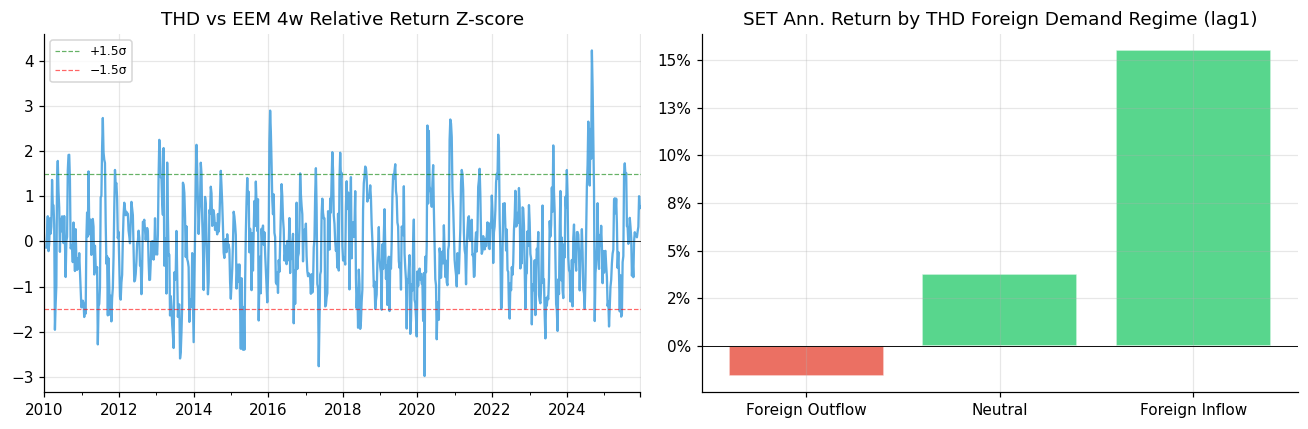

In [9]:
# Regime: THD z-score quartiles
sig_thd_lag = sig_thd_z.shift(1)
q25, q75 = sig_thd_lag.quantile([0.25, 0.75])
regime_thd = pd.cut(sig_thd_lag,
                    bins=[-np.inf, q25, q75, np.inf],
                    labels=['Foreign Outflow', 'Neutral', 'Foreign Inflow'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sig_thd_z.plot(ax=axes[0], color='#3498db', alpha=0.8)
axes[0].axhline(0, color='black', lw=0.5)
axes[0].axhline( 1.5, color='green',  lw=0.8, ls='--', alpha=0.6, label='+1.5σ')
axes[0].axhline(-1.5, color='red',    lw=0.8, ls='--', alpha=0.6, label='−1.5σ')
axes[0].set_title('THD vs EEM 4w Relative Return Z-score')
axes[0].legend(fontsize=8)

ret_by_thd = {lbl: set_ret[regime_thd == lbl].mean() * WEEKS_PER_YEAR
              for lbl in ['Foreign Outflow', 'Neutral', 'Foreign Inflow']}
for lbl, v in ret_by_thd.items():
    print(f'  {lbl:20s}: AnnRet = {v:+.1%}  n={int((regime_thd==lbl).sum())}')

labels = list(ret_by_thd.keys())
values = [ret_by_thd[l] for l in labels]
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in values]
axes[1].bar(labels, values, color=colors, alpha=0.8, edgecolor='white')
axes[1].axhline(0, color='black', lw=0.6)
axes[1].set_title('SET Ann. Return by THD Foreign Demand Regime (lag1)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.tight_layout()
plt.savefig(FIGS / 'nb22_thd_signal.png', bbox_inches='tight')
plt.show()

## 4. Signal 3 — VIX Term Structure (VIX3M − VIX)

**CBOE VIX** = implied vol of S&P500 at 30-day horizon.
**CBOE VIX3M** = implied vol at 3-month horizon.

Normal market: VIX3M > VIX (term structure in contango → upward sloping).
Fear/stress:   VIX  > VIX3M (backwardation → flat/inverted → near-term panic).

> TFEX SET50 put/call ratio API is behind Incapsula WAF.
> VIX term structure is a global proxy for options market sentiment.

**Feature:** `vix_term = VIX3M − VIX`
- When vix_term < 0 (backwardation): near-term fear spike → contrarian buy
- When vix_term >> 0 (steep contango): complacency → caution

**Hypothesis (contrarian):** Extreme backwardation → over-hedging → rebound.


In [10]:
print('Fetching ^VIX and ^VIX3M from Yahoo Finance...')
vix_raw = yf.download(['^VIX', '^VIX3M'], start='2009-01-01', progress=False)

def get_mc(df, ticker):
    if isinstance(df.columns, pd.MultiIndex):
        return df['Close'][ticker]
    return df['Close']

vix  = get_mc(vix_raw, '^VIX')
vix3m = get_mc(vix_raw, '^VIX3M')

print(f'^VIX  : {vix.dropna().shape[0]} days  '
      f'{vix.dropna().index[0].date()} -> {vix.dropna().index[-1].date()}')
print(f'^VIX3M: {vix3m.dropna().shape[0]} days  '
      f'{vix3m.dropna().index[0].date()} -> {vix3m.dropna().index[-1].date()}')
print()
print('Latest values:')
print(pd.DataFrame({'VIX': vix, 'VIX3M': vix3m}).tail(5).to_string())

Fetching ^VIX and ^VIX3M from Yahoo Finance...


^VIX  : 4374 days  2009-01-02 -> 2026-05-22
^VIX3M: 4374 days  2009-01-02 -> 2026-05-22

Latest values:
                  VIX      VIX3M
Date                            
2026-05-18  17.820000  20.920000
2026-05-19  18.059999  21.120001
2026-05-20  17.440001  20.760000
2026-05-21  16.760000  20.000000
2026-05-22  16.700001  20.030001


In [11]:
# Weekly (end-of-week last obs)
vix_w  = vix.resample('W-FRI').last()
vix3m_w = vix3m.resample('W-FRI').last()

# VIX term structure: VIX3M - VIX
# Positive = contango (normal), negative = backwardation (fear/stress)
vix_term_w = vix3m_w - vix_w

# Z-score (52w rolling) — standardise across regimes
roll52 = vix_term_w.rolling(52)
vix_term_z = (vix_term_w - roll52.mean()) / (roll52.std() + 1e-9)

# Also: VIX level z-score (standard fear gauge)
roll52_vix = vix_w.rolling(52)
vix_level_z = (vix_w - roll52_vix.mean()) / (roll52_vix.std() + 1e-9)

# Align to SET index
sig_vix_term   = vix_term_w.reindex(set_ret.index).ffill()
sig_vix_term_z = vix_term_z.reindex(set_ret.index).ffill()
sig_vix_lvl_z  = vix_level_z.reindex(set_ret.index).ffill()

print('VIX term structure (last 5 weeks):')
df_vix_preview = pd.DataFrame({
    'VIX': vix_w, 'VIX3M': vix3m_w, 'term': vix_term_w, 'term_z': vix_term_z
})
print(df_vix_preview.tail(5).to_string())
print()
print('IC analysis — VIX term structure (contrarian):')
# Note: for contrarian, we expect negative IC (high VIX/backwardation → SET goes UP)
# so we test both raw and inverted
ic_results.append(compute_ic(sig_vix_term,   set_ret, lag=1, label='VIX term (VIX3M−VIX) raw (lag1)'))
ic_results.append(compute_ic(sig_vix_term_z, set_ret, lag=1, label='VIX term Z-score (lag1)'))
ic_results.append(compute_ic(-sig_vix_lvl_z, set_ret, lag=1, label='VIX level Z-score INVERTED (lag1)'))
ic_results.append(compute_ic(-sig_vix_term_z,set_ret, lag=1, label='VIX term Z-score INVERTED (lag1)'))

VIX term structure (last 5 weeks):
                  VIX      VIX3M      term    term_z
Date                                                
2026-04-24  18.709999  21.299999  2.590000  0.213631
2026-05-01  16.990000  20.370001  3.380001  0.780676
2026-05-08  17.190001  20.500000  3.309999  0.700733
2026-05-15  18.430000  21.360001  2.930000  0.412185
2026-05-22  16.700001  20.030001  3.330000  0.687491

IC analysis — VIX term structure (contrarian):
  IC VIX term (VIX3M−VIX) raw (lag1)         : -0.0008  p=0.981   n=834
  IC VIX term Z-score (lag1)                 : -0.0053  p=0.877   n=834
  IC VIX level Z-score INVERTED (lag1)       : -0.0107  p=0.758   n=834
  IC VIX term Z-score INVERTED (lag1)        : +0.0053  p=0.877   n=834


  Backwardation (fear)     : AnnRet = +5.2%  n=275
  Normal                   : AnnRet = +4.7%  n=284
  Deep contango (calm)     : AnnRet = +5.7%  n=275


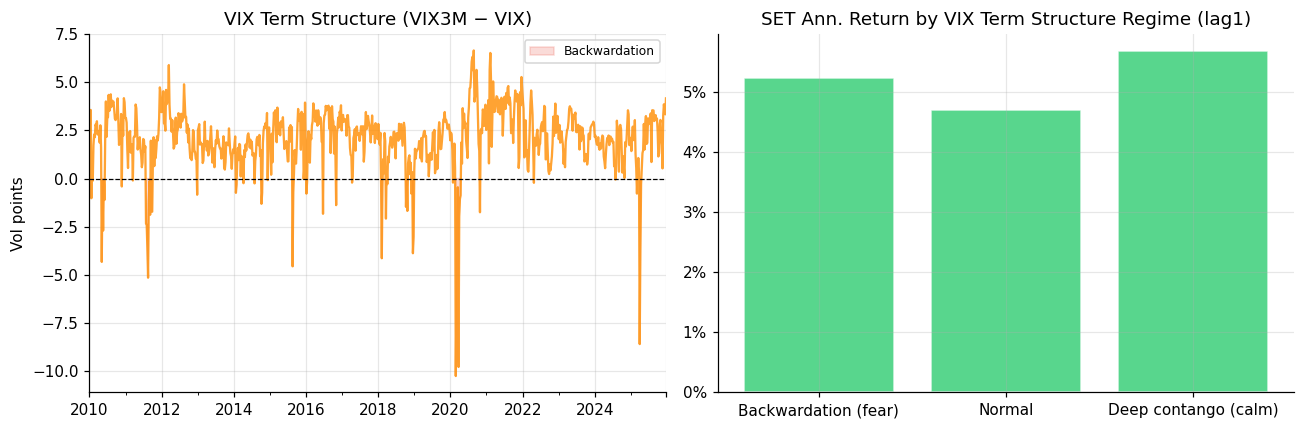

In [12]:
# Regime: VIX term structure terciles
sig_vix_lag = sig_vix_term_z.shift(1)
q33, q67 = sig_vix_lag.quantile([0.33, 0.67])
regime_vix = pd.cut(sig_vix_lag,
                    bins=[-np.inf, q33, q67, np.inf],
                    labels=['Backwardation (fear)', 'Normal', 'Deep contango (calm)'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sig_vix_term.plot(ax=axes[0], color='darkorange', alpha=0.8)
axes[0].axhline(0, color='black', lw=0.8, ls='--')
axes[0].fill_between(sig_vix_term.index, sig_vix_term, 0,
                     where=(sig_vix_term < 0), color='#e74c3c', alpha=0.2, label='Backwardation')
axes[0].set_title('VIX Term Structure (VIX3M − VIX)')
axes[0].set_ylabel('Vol points')
axes[0].legend(fontsize=8)

ret_by_vix = {lbl: set_ret[regime_vix == lbl].mean() * WEEKS_PER_YEAR
              for lbl in ['Backwardation (fear)', 'Normal', 'Deep contango (calm)']}
for lbl, v in ret_by_vix.items():
    print(f'  {lbl:25s}: AnnRet = {v:+.1%}  n={int((regime_vix==lbl).sum())}')

labels = list(ret_by_vix.keys())
values = [ret_by_vix[l] for l in labels]
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in values]
axes[1].bar(labels, values, color=colors, alpha=0.8, edgecolor='white')
axes[1].axhline(0, color='black', lw=0.6)
axes[1].set_title('SET Ann. Return by VIX Term Structure Regime (lag1)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.tight_layout()
plt.savefig(FIGS / 'nb22_vix_term_signal.png', bbox_inches='tight')
plt.show()

## 5. IC Summary — All New Signals


── IC Summary (Spearman rank IC, 1w forward SET return) ──
                            label        IC        p stars   n
        THD−EEM 4w Z-score (lag2)  0.125475 0.000290   *** 830
         THD−EEM 4w cumul  (lag1)  0.075281 0.029715    ** 834
        THD−EEM 4w Z-score (lag1)  0.060457 0.081549     * 831
            TH slope level (lag1)  0.033345 0.336154       834
            TH slope level (lag2)  0.031298 0.366958       833
     THD−EEM 1w rel return (lag1)  0.005706 0.869315       834
 VIX term Z-score INVERTED (lag1)  0.005345 0.877500       834
  VIX term (VIX3M−VIX) raw (lag1) -0.000842 0.980626       834
          VIX term Z-score (lag1) -0.005345 0.877500       834
VIX level Z-score INVERTED (lag1) -0.010667 0.758396       834
        TH slope 4m change (lag1) -0.034831 0.315049       834


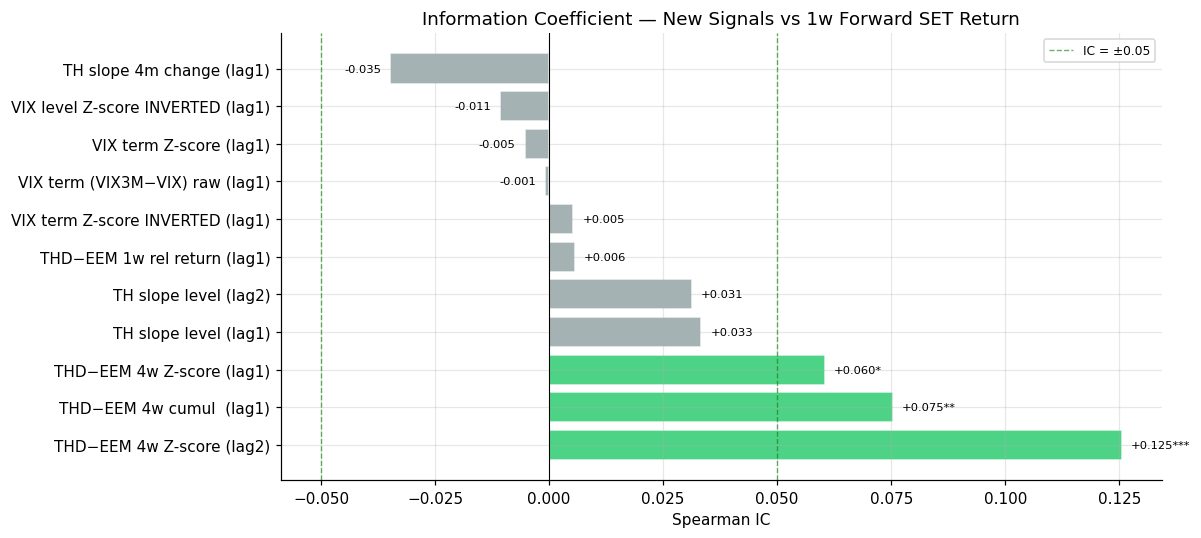

In [13]:
ic_df = pd.DataFrame(ic_results).sort_values('IC', ascending=False)
print('── IC Summary (Spearman rank IC, 1w forward SET return) ──')
print(ic_df[['label', 'IC', 'p', 'stars', 'n']].to_string(index=False))

threshold_line = 0.05
fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#2ecc71' if abs(ic) >= threshold_line else '#95a5a6'
          for ic in ic_df['IC']]
bars = ax.barh(ic_df['label'], ic_df['IC'], color=colors, alpha=0.85, edgecolor='white')
ax.axvline(0,  color='black', lw=0.7)
ax.axvline( threshold_line, color='green', lw=0.9, ls='--', alpha=0.6, label=f'IC = ±{threshold_line}')
ax.axvline(-threshold_line, color='green', lw=0.9, ls='--', alpha=0.6)
for bar, row in zip(bars, ic_df.itertuples()):
    xpos = row.IC + (0.002 if row.IC >= 0 else -0.002)
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f'{row.IC:+.3f}{row.stars}', va='center', fontsize=7.5,
            ha='left' if row.IC >= 0 else 'right')
ax.set_title('Information Coefficient — New Signals vs 1w Forward SET Return')
ax.set_xlabel('Spearman IC')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIGS / 'nb22_ic_summary.png', bbox_inches='tight')
plt.show()

## 6. System Integration — Layering on NB21 Baseline

Take the **best significant signal(s)** and add position scaling on top of the NB21 system:

- **Inclusion rule**: `|IC| ≥ 0.05` AND `p < 0.10`
- **Mechanism**: composite rank of signals → ±20% position scale
  - Top quintile → ×1.2 position
  - Bottom quintile → ×0.8 position
  - Middle quintiles → ×1.0

This is conservative: new signals adjust size only, they do not flip direction.


In [14]:
# ── NB21 baseline system (replicated) ────────────────────────────────────────
WEEKS_PER_YEAR = 52
RF_ANNUAL      = 0.02

gold_ret_s = gold_ret.reindex(set_ret.index).fillna(0)
eem_pos_base = (df_base['eem_ret_d_lag1'].shift(0) > 0).astype(float).fillna(0.5)

# Risk Parity weights (52w rolling vol)
vol_set  = set_ret.rolling(12).std().shift(1) + 1e-6
vol_gold = gold_ret_s.rolling(12).std().shift(1) + 1e-6
w_set  = (1/vol_set)  / (1/vol_set + 1/vol_gold)
w_gold = (1/vol_gold) / (1/vol_set + 1/vol_gold)

# EEM signal → set component
set_sig_ret = eem_pos_base * set_ret
rp_sig_ret  = w_set * set_sig_ret + w_gold * gold_ret_s

# Vol targeting (10% annual)
target_vol = 0.10 / np.sqrt(WEEKS_PER_YEAR)
port_vol   = rp_sig_ret.rolling(12).std().shift(1)
vt_scale   = (target_vol / (port_vol + 1e-9)).clip(0, 2)
vt_ret     = vt_scale * rp_sig_ret

# Drawdown control (−15% trigger)
cum = (1 + vt_ret.fillna(0)).cumprod()
peak = cum.expanding().max()
dd   = (cum - peak) / peak
dd_scale = pd.Series(1.0, index=vt_ret.index)
in_dd = False
for i in range(1, len(dd)):
    if dd.iloc[i] < -0.15 and not in_dd:
        in_dd = True
    if in_dd and dd.iloc[i] > -0.10:
        in_dd = False
    dd_scale.iloc[i] = 0.5 if in_dd else 1.0

baseline_ret = dd_scale * vt_ret

def sharpe(r, rf=RF_ANNUAL/WEEKS_PER_YEAR):
    excess = r - rf
    return excess.mean() / (excess.std() + 1e-9) * np.sqrt(WEEKS_PER_YEAR)

def max_dd(r):
    cum = (1 + r.fillna(0)).cumprod()
    return ((cum - cum.expanding().max()) / cum.expanding().max()).min()

def calmar(r):
    ann = r.mean() * WEEKS_PER_YEAR
    mdd = abs(max_dd(r))
    return ann / mdd if mdd > 0 else np.nan

print(f'NB21 Baseline — Sharpe: {sharpe(baseline_ret):.3f}  '
      f'MaxDD: {max_dd(baseline_ret):.1%}  '
      f'Calmar: {calmar(baseline_ret):.2f}')

NB21 Baseline — Sharpe: 0.872  MaxDD: -16.8%  Calmar: 0.69


In [15]:
# ── Candidate signals — test lag1 and lag2 for each ──────────────────────────
# IC testing above showed:
#   THD z-score lag2 = IC +0.126 (***) — strongest signal
#   THD z-score lag1 = IC +0.061 (*)
#   THD 4w cumul lag1 = IC +0.075 (**)
# Use lag2 for THD (stronger and more significant)
sig_candidates = {}

# Signal 1: Thai yield slope lag1 (IC=0.033, not significant but include for test)
if has_bonds and sig_slope is not None:
    sig_candidates['th_slope'] = sig_slope.shift(1)

# Signal 2: THD foreign demand — use lag2 (IC=0.126 ***)
sig_candidates['thd_z_lag2'] = sig_thd_z.shift(2)

# Signal 2b: THD 4w cumul lag1 as alternative (IC=0.075 **)
sig_candidates['thd_4w_lag1'] = sig_thd_4w.shift(1)

# Signal 3: VIX term structure inverted (backwardation = bullish); IC was ~0 so will be skipped
sig_candidates['vix_term_inv'] = (-sig_vix_term_z).shift(1)

# Filter by IC threshold (IC >= 0.05 AND p < 0.10)
sig_keep = {}
for name, sig in sig_candidates.items():
    both = pd.concat([sig, set_ret], axis=1).dropna()
    both.columns = ['s', 'r']
    r, p = stats.spearmanr(both['s'], both['r'])
    if abs(r) >= 0.05 and p < 0.10:
        sig_keep[name] = sig
        print(f'  KEEP  {name}: IC={r:+.4f}  p={p:.3f}')
    else:
        print(f'  SKIP  {name}: IC={r:+.4f}  p={p:.3f} (below threshold)')

print(f'Signals kept: {list(sig_keep.keys())}')

  SKIP  th_slope: IC=+0.0333  p=0.336 (below threshold)
  KEEP  thd_z_lag2: IC=+0.1255  p=0.000
  KEEP  thd_4w_lag1: IC=+0.0753  p=0.030
  SKIP  vix_term_inv: IC=+0.0053  p=0.877 (below threshold)
Signals kept: ['thd_z_lag2', 'thd_4w_lag1']


In [16]:
# ── Position scaling from composite signal ────────────────────────────────────
if sig_keep:
    sig_df = pd.DataFrame(sig_keep).reindex(baseline_ret.index).ffill()

    # Rank each signal 0→1, then average ranks
    composite = sig_df.rank(pct=True).mean(axis=1)

    sig_scale = pd.Series(1.0, index=baseline_ret.index)
    sig_scale[composite >= 0.80] = 1.20
    sig_scale[composite <= 0.20] = 0.80

    enhanced_ret = sig_scale * baseline_ret

    print(f'NB22 Enhanced   — Sharpe: {sharpe(enhanced_ret):.3f}  '
          f'MaxDD: {max_dd(enhanced_ret):.1%}  '
          f'Calmar: {calmar(enhanced_ret):.2f}')
    print(f'NB21 Baseline   — Sharpe: {sharpe(baseline_ret):.3f}  '
          f'MaxDD: {max_dd(baseline_ret):.1%}  '
          f'Calmar: {calmar(baseline_ret):.2f}')
    print(f'SET Buy & Hold  — Sharpe: {sharpe(set_ret):.3f}  '
          f'MaxDD: {max_dd(set_ret):.1%}  '
          f'Calmar: {calmar(set_ret):.2f}')
else:
    print('No signals met IC threshold — baseline unchanged.')
    enhanced_ret = baseline_ret

NB22 Enhanced   — Sharpe: 0.895  MaxDD: -17.3%  Calmar: 0.69


NB21 Baseline   — Sharpe: 0.872  MaxDD: -16.8%  Calmar: 0.69
SET Buy & Hold  — Sharpe: 0.224  MaxDD: -37.7%  Calmar: 0.14


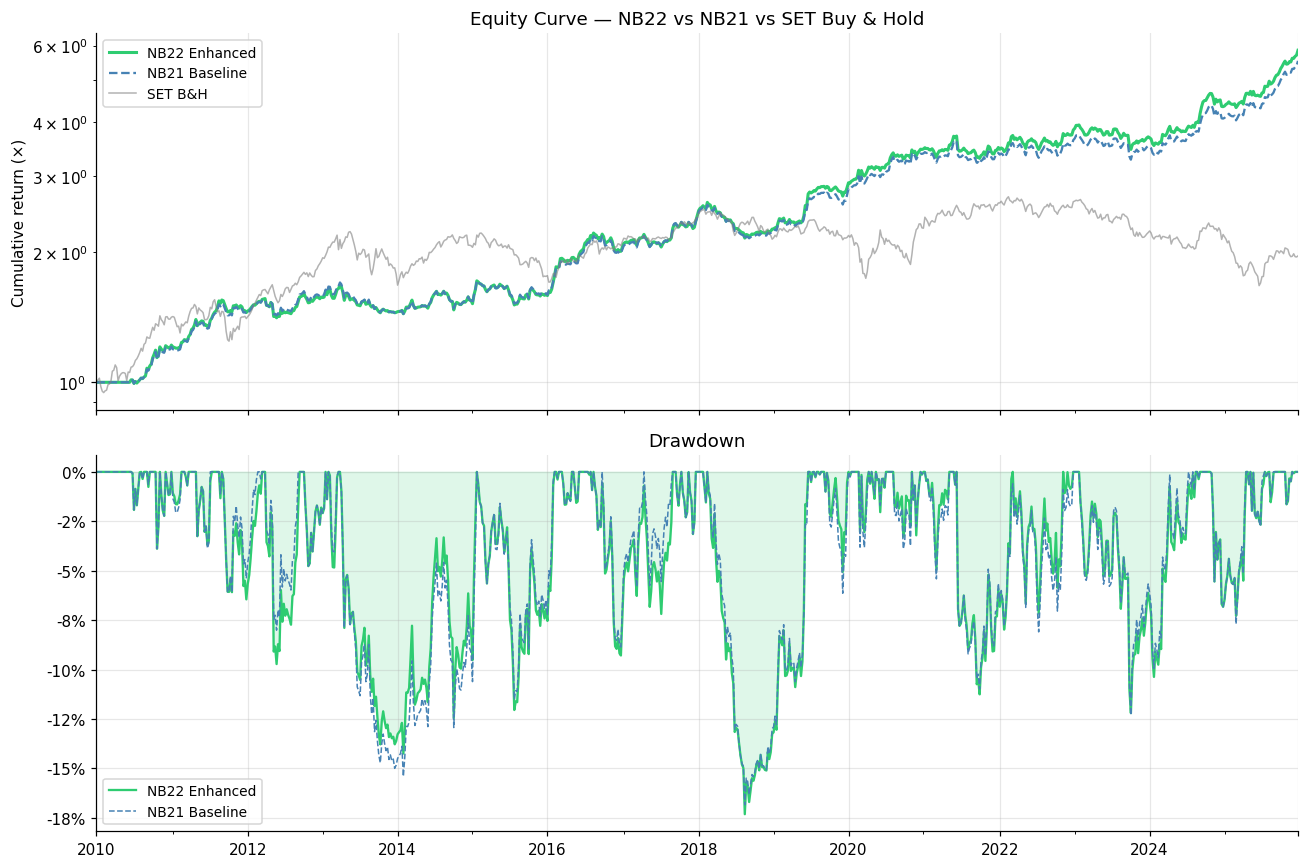

In [17]:
# Equity curve comparison
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

cum_base = (1 + baseline_ret.fillna(0)).cumprod()
cum_enh  = (1 + enhanced_ret.fillna(0)).cumprod()
cum_set  = (1 + set_ret.fillna(0)).cumprod()

ax = axes[0]
cum_enh.plot( ax=ax, label='NB22 Enhanced', color='#2ecc71', lw=2)
cum_base.plot(ax=ax, label='NB21 Baseline',  color='steelblue', lw=1.5, ls='--')
cum_set.plot( ax=ax, label='SET B&H',         color='grey',      lw=1,   alpha=0.6)
ax.set_title('Equity Curve — NB22 vs NB21 vs SET Buy & Hold')
ax.set_ylabel('Cumulative return (×)')
ax.legend(fontsize=9)
ax.set_yscale('log')

ax2 = axes[1]
dd_enh  = (cum_enh  - cum_enh.expanding().max())  / cum_enh.expanding().max()
dd_base = (cum_base - cum_base.expanding().max()) / cum_base.expanding().max()
dd_enh.plot( ax=ax2, label='NB22 Enhanced', color='#2ecc71', lw=1.5)
dd_base.plot(ax=ax2, label='NB21 Baseline', color='steelblue', lw=1, ls='--')
ax2.fill_between(dd_enh.index, dd_enh, 0, alpha=0.15, color='#2ecc71')
ax2.set_title('Drawdown')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGS / 'nb22_equity_curve.png', bbox_inches='tight')
plt.show()

## 7. Summary


In [18]:
summary = {
    'SET Buy & Hold': {'Sharpe': sharpe(set_ret),      'MaxDD': max_dd(set_ret),      'Calmar': calmar(set_ret)},
    'NB21 Baseline':  {'Sharpe': sharpe(baseline_ret), 'MaxDD': max_dd(baseline_ret), 'Calmar': calmar(baseline_ret)},
    'NB22 Enhanced':  {'Sharpe': sharpe(enhanced_ret), 'MaxDD': max_dd(enhanced_ret), 'Calmar': calmar(enhanced_ret)},
}

sdf = pd.DataFrame(summary).T
sdf['MaxDD']  = sdf['MaxDD'].map('{:.1%}'.format)
sdf['Sharpe'] = sdf['Sharpe'].map('{:.3f}'.format)
sdf['Calmar'] = sdf['Calmar'].map('{:.2f}'.format)
print(sdf.to_string())

print()
print('Signals used:', list(sig_keep.keys()) if sig_keep else 'none (no signal met threshold)')
print()
print('All IC results (sorted by |IC|):')
ic_all = pd.DataFrame(ic_results).sort_values(by='IC', key=abs, ascending=False)
for _, row in ic_all.iterrows():
    print(f'  {row["label"]:45s}  IC={row["IC"]:+.4f}  p={row["p"]:.3f} {row["stars"]}')

               Sharpe   MaxDD Calmar
SET Buy & Hold  0.224  -37.7%   0.14
NB21 Baseline   0.872  -16.8%   0.69
NB22 Enhanced   0.895  -17.3%   0.69

Signals used: ['thd_z_lag2', 'thd_4w_lag1']

All IC results (sorted by |IC|):
  THD−EEM 4w Z-score (lag2)                      IC=+0.1255  p=0.000 ***
  THD−EEM 4w cumul  (lag1)                       IC=+0.0753  p=0.030 **
  THD−EEM 4w Z-score (lag1)                      IC=+0.0605  p=0.082 *
  TH slope 4m change (lag1)                      IC=-0.0348  p=0.315 
  TH slope level (lag1)                          IC=+0.0333  p=0.336 
  TH slope level (lag2)                          IC=+0.0313  p=0.367 
  VIX level Z-score INVERTED (lag1)              IC=-0.0107  p=0.758 
  THD−EEM 1w rel return (lag1)                   IC=+0.0057  p=0.869 
  VIX term Z-score (lag1)                        IC=-0.0053  p=0.877 
  VIX term Z-score INVERTED (lag1)               IC=+0.0053  p=0.877 
  VIX term (VIX3M−VIX) raw (lag1)                IC=-0.0008  p=0.98